# Phase 3 · Notebook 2 — 02_Market_Basket_Analysis
Association rules va **mlxtend Apriori** on real order co-occurrence (replaces sentiment analysis — no review text exists in this dataset).

**Verified-schema honesty:** orders carry `restaurant_id` but **no item link** — a user x food_id matrix is impossible to build honestly. The most granular honest unit is **user x cuisine-tag** (via restaurant.cuisine): 'which cuisine combinations does a customer consume?' — exactly what cross-promotion needs.

### Reporting rules (Phase 0 findings, unchanged)
- **R1** Headline money = `currency='INR'` (USD segment measured & excluded)
- **R2** Reference "today" = `MAX(order_datetime)` in the data
- **R3** NULL-FK rows kept in overall aggregates, drop out of restaurant rollups


## Setup

In [1]:
# ---- boilerplate: paths, DB engine (SQLAlchemy from .env), helper --------
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ROOT = Path.cwd()
if not (ROOT / "python").is_dir() and (ROOT.parent / "python").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "python" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
load_dotenv(ROOT / ".env")

DB_URL = os.getenv("DATABASE_URL")
assert DB_URL, "DATABASE_URL missing - check .env in the repo root"
engine = create_engine(DB_URL)

def q(sql):
    """read_sql via text(): keeps parameters=None so literal '%' in ILIKE is safe."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("ROOT:", ROOT, "| OUT:", OUT, "| DB connected OK", sep="\n")


ROOT:
D:\Projects\bharatinsight
| OUT:
D:\Projects\bharatinsight\python\outputs
| DB connected OK


## Step 1 — user × cuisine binary basket matrix (from real orders)

In [2]:
baskets = q("""
SELECT o.user_id, trim(tag) AS cuisine
FROM orders o
JOIN restaurant r ON r.restaurant_id = o.restaurant_id,
     LATERAL unnest(string_to_array(r.cuisine, ',')) AS tag
WHERE o.user_id IS NOT NULL AND r.cuisine IS NOT NULL
GROUP BY o.user_id, trim(tag)
""")
print("user-cuisine rows:", len(baskets))
basket = pd.crosstab(baskets["user_id"], baskets["cuisine"]).astype(bool)
print("basket matrix:", basket.shape, "| cuisines:", list(basket.columns))

user-cuisine rows: 236130


basket matrix: (77569, 126) | cuisines: ['8:15 To 11:30 Pm', 'Afghani', 'African', 'American', 'Andhra', 'Arabian', 'Asian', 'Assamese', 'Attractive Combos Available', 'Australian', 'Awadhi', 'BEVERAGE', 'Bakery', 'Bakery products', 'Bangladeshi', 'Barbecue', 'Bengali', 'Beverages', 'Bhutanese', 'Bihari', 'Biryani', 'Biryani - Shivaji Military Hotel', 'Bowl Company', 'British', 'Burgers', 'Burmese', 'Cafe', 'Chaat', 'Chettinad', 'Chinese', 'Coastal', 'Code valid on bill over Rs.99', 'Combo', 'Continental', 'Default', 'Desserts', 'Discount offer from Garden Cafe Express Kankurgachi', 'European', 'Fast Food', 'Free Delivery ! Limited Stocks!', 'French', 'German', 'Goan', 'Greek', 'Grill', 'Grocery products', 'Gujarati', 'Haleem', 'Healthy Food', 'Home Food', 'Hyderabadi', 'Ice Cream', 'Ice Cream Cakes', 'Indian', 'Indonesian', 'Italian', 'Italian-American', 'Jain', 'Japanese', 'Juices', 'Kashmiri', 'Kebabs', 'Kerala', 'Keto', 'Khasi', 'Konkan', 'Korean', 'Lebanese', 'Lucknowi', 'MAX 2 Co

## Step 2 — Apriori frequent itemsets (min_support tuned to scale)

In [3]:
from mlxtend.frequent_patterns import apriori, association_rules
MIN_SUPPORT = 0.01   # 1% of ~100k users ~= 1000 baskets — scale-appropriate
freq = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
print("frequent itemsets:", len(freq))
print(freq.sort_values("support", ascending=False).head(10)
          .assign(itemsets=lambda d: d["itemsets"].astype(str)).to_string(index=False))

frequent itemsets: 181
 support                               itemsets
0.394629                 frozenset({'Chinese'})
0.359448            frozenset({'North Indian'})
0.293261                  frozenset({'Indian'})
0.204618                  frozenset({'Snacks'})
0.175083                 frozenset({'Biryani'})
0.171924               frozenset({'Beverages'})
0.170326 frozenset({'North Indian', 'Chinese'})
0.167386               frozenset({'Fast Food'})
0.146128            frozenset({'South Indian'})
0.139089       frozenset({'Chinese', 'Indian'})


## Step 3 — association rules, sorted by LIFT (top 20)

In [4]:
rules = association_rules(freq, metric="lift", min_threshold=1.0)
top = (rules[["antecedents","consequents","support","confidence","lift"]]
       .sort_values("lift", ascending=False).head(20).copy())
for c in ["antecedents","consequents"]:
    top[c] = top[c].apply(lambda s: " + ".join(sorted(s)))
top[["support","confidence","lift"]] = top[["support","confidence","lift"]].round(3)
print("rules found:", len(rules))
display(top)

rules found: 332


,antecedents,consequents,support,confidence,lift
44,Ice Cream,Desserts,0.036,0.537,3.921
45,Desserts,Ice Cream,0.036,0.262,3.921
271,Desserts,Ice Cream + North Indian,0.010,0.073,3.874
268,Ice Cream + North Indian,Desserts,0.010,0.531,3.874
192,Chinese + Ice Cream,Desserts,0.011,0.523,3.821
195,Desserts,Chinese + Ice Cream,0.011,0.079,3.821
193,Chinese + Desserts,Ice Cream,0.011,0.252,3.763
194,Ice Cream,Chinese + Desserts,0.011,0.161,3.763
270,Ice Cream,Desserts + North Indian,0.010,0.150,3.706
269,Desserts + North Indian,Ice Cream,0.010,0.248,3.706


## Step 4 — top rules as lift bar chart

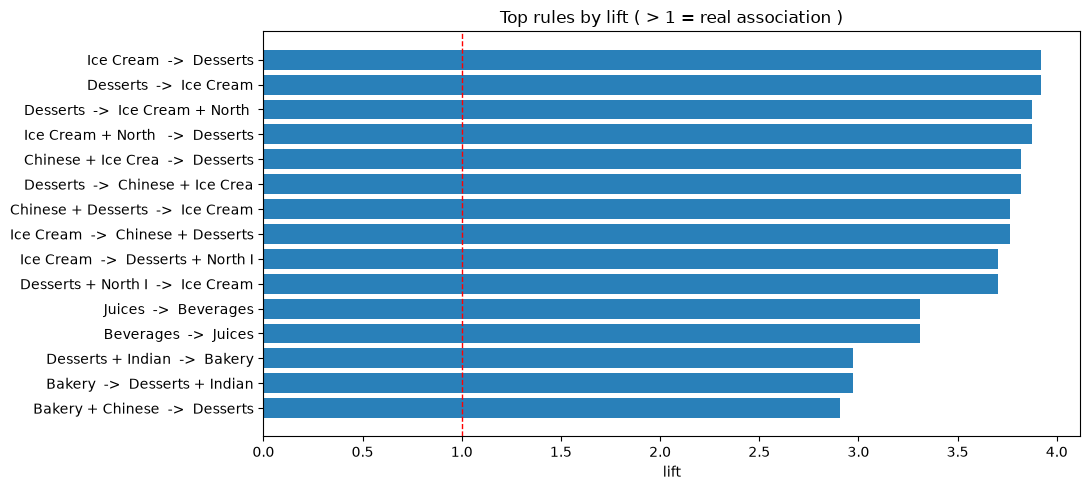

In [5]:
plot = top.head(15).copy()
plot["rule"] = plot["antecedents"].str[:18] + "  ->  " + plot["consequents"].str[:18]
fig, ax = plt.subplots(figsize=(11,5))
ax.barh(plot["rule"][::-1], plot["lift"][::-1], color="#2980b9")
ax.axvline(1.0, color="red", ls="--", lw=1); ax.set_title("Top rules by lift ( > 1 = real association )")
ax.set_xlabel("lift")
fig.tight_layout(); fig.savefig(OUT/"basket_lift.png", dpi=150); plt.show()

## Step 5 — interpretation of the top 3 pairs

In [6]:
for _, r in top.head(3).iterrows():
    print(f"* Users who order {r['antecedents']} also order {r['consequents']} "
          f"(lift {r['lift']}x, confidence {100*r['confidence']:.0f}%, support {100*r['support']:.1f}%)")
    print("  -> bundle/cross-promo candidate.\n")
print("Reading: lift 1 = independent; lift > 1.2 = a real, actionable association.")

* Users who order Ice Cream also order Desserts (lift 3.921x, confidence 54%, support 3.6%)
  -> bundle/cross-promo candidate.

* Users who order Desserts also order Ice Cream (lift 3.921x, confidence 26%, support 3.6%)
  -> bundle/cross-promo candidate.

* Users who order Desserts also order Ice Cream + North Indian (lift 3.874x, confidence 7%, support 1.0%)
  -> bundle/cross-promo candidate.

Reading: lift 1 = independent; lift > 1.2 = a real, actionable association.
